In [3]:
import os
import pickle
import numpy as np
import torch
from model.UAV import *
from model.HAP import *
from testing_func.test_func import *

ali
Hotspot center: [1076.70912372  432.65058173]


In [ ]:
from model.HAP import *
from model.UAV import *
from network_models.users import *
from network_models.cloud_model import *
from network_models.parameters import *
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import trange
import random
from network_models.multi_sat import *
from satellite.satellite_model import *

In [6]:
import torch.nn.functional as F
def select_action_topk(top_list, Q_net, obs, prev_selected_sat=None, epsilon=0.1):
    n_valid = len(top_list)
    if n_valid == 0:
        return None, None, 0

    # kiểm tra prev có thực sự tồn tại trong top_list hay không
    prev_valid = False
    if prev_selected_sat is not None:
        prev_valid = any(s[0] == prev_selected_sat for s in top_list)

    # convert obs sang tensor
    if isinstance(obs, np.ndarray):
        obs_t = torch.tensor(obs, dtype=torch.float32, device=next(Q_net.parameters()).device)
    else:
        obs_t = obs.to(next(Q_net.parameters()).device)

    with torch.no_grad():
        q_full = Q_net(obs_t.unsqueeze(0)).squeeze(0).cpu().numpy()

    action_space_size = q_full.shape[0]
    n_consider = min(action_space_size, n_valid)

    # --- Exploration ---
    # if np.random.rand() < epsilon:
    #     if prev_valid:
    #         action_idx = int(np.random.randint(0, n_consider))
    #     else:
    #         if n_consider > 1:
    #             action_idx = int(np.random.randint(1, n_consider))  # bỏ index 0 nếu prev k có
    #         else:
    #             action_idx = 0  # chỉ còn 1 lựa chọn
    #     selected_sat_name = top_list[action_idx][0]
    #     keep_flag = 1 if (prev_selected_sat is not None and selected_sat_name == prev_selected_sat) else 0
    #     return action_idx, selected_sat_name, keep_flag

    # --- Exploitation ---
    q_masked = np.full_like(q_full, -np.inf, dtype=float)
    q_masked[:n_consider] = q_full[:n_consider]
    # if not prev_valid:
    #     q_masked[0] = -np.inf  # loại bỏ padding ở index 0

    action_idx = int(np.argmax(q_masked))
    selected_sat_name = top_list[action_idx][0]
    keep_flag = 1 if (prev_selected_sat is not None and selected_sat_name == prev_selected_sat) else 0
    return action_idx, selected_sat_name, keep_flag

In [7]:
def select_action_topk_cfso(topk_list, prev_selected_sat=None):
    n_valid = len(topk_list)
    if n_valid == 0:
        return None, None, 0  # không có vệ tinh để chọn
    best_local_idx = max(range(len(topk_list)), key=lambda i: topk_list[i][4])
    action_idx = best_local_idx
    selected_sat_name = topk_list[action_idx][0]  # sat_name là phần tử đầu tiên

    # giữ kết nối nếu trùng vệ tinh step trước
    keep_idx = 1 if prev_selected_sat is not None and selected_sat_name == prev_selected_sat else 0

    return action_idx, selected_sat_name, keep_idx


In [10]:

def evaluate_trained_policy_2(
     sat_per_step,device, num_uav, num_steps,
    uav_pos_init, user_positions, cloud_map, HAP_position, type_SAT,save_dir="/kaggle/working/"
):
 
    
    Q_nets_UAV = [QNetwork_UAV(142, 5).to(device) for _ in range(num_uav)]
    Q_nets_HAP = QNetwork_HAP(63, 30).to(device)

    # --- Load HAP models ---
    Q_nets_HAP.load_state_dict(torch.load("/kaggle/input/14e10continue/HAP_14e10.pth"))

    for i in range(num_uav):
        Q_nets_UAV[i].load_state_dict(torch.load(os.path.join(save_dir, f"UAV/UAV{i}_ep{2500}.pth")))


    alpha, beta = None, None
    RUAV_log = []
    CFSO_log = []
    uav_traj = []
    HAP_bandwidth_log = []
    visible_time_log = []
    uav_pos = uav_pos_init.copy()
    alpha_all = []
    beta_all = []
    actions_uav = []
    sat_name_per_step = []
    region_t, clwc_map_t, new_cloud_map = get_clwc_map(cloud_map)
    current_satellite_id = None 
    prev_satellite_id = None
    nums_handover = 0
    CFSO_REAL = []
    alpha, beta, C_FSO_UAV_before = get_CFSO(
                uav_pos, user_positions[:,0,:], region_t, HAP_position, actions_uav, 0, device
            )
    reward_fu = 0
    for t in range(900):
        region_t, clwc_map_t, new_cloud_map = get_clwc_map(cloud_map)
        cloud_map = new_cloud_map
        user_pos_t = user_positions[:, t, :]

       
        alpha, beta, C_FSO_UAV_before = get_CFSO(
                uav_pos, user_positions[:,t,:], region_t, HAP_position, actions_uav, 0, device
            )
        
        obs_hap, top_list = build_observation_hap(t, sat_per_step, C_FSO_UAV_before/(1.8e10), prev_satellite_id)
        obs_hap = torch.tensor(obs_hap, dtype=torch.float32, device=device)
        # print(f"Step {t}, Obs HAP: {obs_hap.cpu().numpy()}")
        sat_that_step = sat_per_step.get(t, [])
        if(type_SAT=="Visible"):
            action_idx, current_satellite_id, keep_idx = select_action_topk_visible(
                            sat_that_step, current_satellite_id
                        )
        elif(type_SAT=="DQN"):
            action_idx, current_satellite_id, keep_idx = select_action_topk(top_list, Q_nets_HAP, obs_hap, prev_satellite_id, epsilon=0)
        elif(type_SAT=="best"):
            action_idx, current_satellite_id, keep_idx = select_action_topk_cfso(
                                sat_that_step, current_satellite_id
                            )
        sat_name_bef, elev, vt_bef, slant, HAP_bandwidth_bef,_ = top_list[0]

        if(type_SAT == "DQN"):
            sat_name, elev, vt, slant, c_fso,_ = top_list[action_idx]
        else:
            sat_name, elev, vt, slant, c_fso,_ = sat_that_step[action_idx]
            
        sat_info = {'sat_name': sat_name, 'elev': elev, 'vt': vt, 'slant': slant, 'c_fso': c_fso}
        HAP_bandwidth = sat_info['c_fso'] * 1.4e10
        HAP_bandwidth = HAP_bandwidth 
        U_sum = np.sum(C_FSO_UAV_before)
        reward = hap_reward_2(HAP_bandwidth, U_sum, action_idx, sat_info['vt'])

        obs_uav = build_observations_vector(uav_pos, user_pos_t, clwc_map_t, alpha, beta)
        obs_uav = obs_uav.to(device)
        with torch.no_grad():
            actions = [Q_nets_UAV[i](obs_uav[i].unsqueeze(0)).argmax().item() for i in range(num_uav)]
        
        
        # if(type_SAT == "DQN"):
        #     # print(t)
        #     print(reward)
        #     if(reward == -40):
        #         print(t)
        #         print(U_sum)
        #         print(f" hap before {HAP_bandwidth_bef * 1.8e10}, {vt_bef}")
        #         print(f" hap now {HAP_bandwidth}, {vt}")
        #         # print(sat_that_step)
        # next_region_t, next_clwc_map_t, new_cloud = get_clwc_map(cloud_map)
        user_pos_t = user_positions[:, t, :]

        rewards_uav, alpha, beta, RUAV, CFSO = user_association_and_reward_opti_2(
            uav_pos, user_pos_t, region_t, HAP_position, HAP_bandwidth, t, device
        )
        uav_pos = move_uavs(uav_pos, actions)

        if(prev_satellite_id != current_satellite_id):
            nums_handover += 1
        # if(reward == -40 and type_SAT == "DQN" ):
        #     print(prev_satellite_id)
        #     print(current_satellite_id)
        #     print(sat_info['sat_name'])
        #     print(nums_handover)
        prev_satellite_id = current_satellite_id
        CFSO_REAL.append(C_FSO_UAV_before)
        HAP_bandwidth_log.append(HAP_bandwidth)
        RUAV_log.append(RUAV.cpu().numpy() if isinstance(RUAV, torch.Tensor) else RUAV)
        CFSO_log.append(CFSO.cpu().numpy() if isinstance(CFSO, torch.Tensor) else CFSO)
        sat_name_per_step.append(current_satellite_id)
        visible_time_log.append(sat_info['vt'])
        alpha_all.append(alpha)
        beta_all.append(beta)
        uav_traj.append(uav_pos.copy())
        reward_fu = reward_fu + reward 
    # if(type_SAT == "DQN"):
    #     print(reward_fu)
    return RUAV_log, CFSO_log,CFSO_REAL, uav_traj, alpha_all, beta_all, HAP_bandwidth_log, nums_handover,sat_name_per_step,visible_time_log


In [11]:
# from network_models.multi_sat import get_sat
from network_models.cloud_model import *
sat_per_step = get_random_300(data,901)
num_uav = 3
num_steps = 300
uav_pos_init = np.array([[0, 0, H_OGS],
                         [0, 0, H_OGS],
                         [0, 0, H_OGS]], dtype=np.float32)
user_positions = simulate_user_mobility(200, 901, distribution="normal", n_hotspot=1)
cloud_map_all = get_full_cloud_torch(cloud_size=6, device=device).squeeze().cpu().numpy()
HAP_position = np.array([750, 750, 20000], dtype=np.float32)

In [12]:
for i in range(1):
    print(i)

0


In [13]:
nums_handover_DQN_arr = []
nums_handover_visible_arr = []
nums_handover_best_arr = []
RUAV_log_DQN_arr = [] 
CFSO_log_DQN_arr = [] 
RUAV_log_visible_arr = [] 
CFSO_log_visible_arr = [] 
RUAV_log_best_arr = [] 
CFSO_log_best_arr = [] 
HAP_bw_log_best_arr = []
HAP_bw_log_visible_arr = []
HAP_bw_log_DQN_arr = []
visible_log_best_arr = []
visible_log_visible_arr = []
visible_log_DQN_arr = []
times = 0
for i in range(100):
    print(i)
    sat_per_step = get_random_300(data,901)
    num_uav = 3
    num_steps = 300
    uav_pos_init = np.array([[0, 0, H_OGS],
                             [0, 0, H_OGS],
                             [0, 0, H_OGS]], dtype=np.float32)
    user_positions = simulate_user_mobility(200, 901, distribution="normal", n_hotspot=1)
    cloud_map_all = get_full_cloud_torch(cloud_size=6, device=device).squeeze().cpu().numpy()
    cloud_map = cloud_map_all.copy()
    HAP_position = np.array([750, 750, 20000], dtype=np.float32)
    # print("DQN")
    type_SAT="DQN"  # random, best, DQN
    RUAV_log_DQN, CFSO_log_DQN,CFSO_REAL_dqn, uav_traj_DQN, alpha_all_DQN, beta_all_DQN, HAP_bw_log_DQN, nums_handover_DQN, sat_name_per_step_dqn, visible_time_dqn= evaluate_trained_policy_2(
        sat_per_step,device, num_uav, num_steps,
        uav_pos_init, user_positions, cloud_map, HAP_position, type_SAT, save_dir="/kaggle/input/model-save/model_save"
    )
    # print("best")
    cloud_map = cloud_map_all.copy()

    type_SAT="best"  # random, best, DQN
    RUAV_log_best, CFSO_log_BEST,CFSO_log_real_best, uav_traj_best, alpha_all_best, beta_all_best, HAP_bw_log_best, nums_handover_best, sat_name_per_step_best, visible_time_best= evaluate_trained_policy_2(
        sat_per_step,device, num_uav, num_steps,
        uav_pos_init, user_positions, cloud_map, HAP_position, type_SAT, save_dir="/kaggle/input/model-save/model_save"
    )
    # print("visible")
    cloud_map = cloud_map_all.copy()

    type_SAT="Visible"  # random, best, DQN
    RUAV_log_visible, CFSO_log_visible,CFSO_log_real_visible, uav_traj_visible, alpha_all_visible, beta_all_visible, HAP_bw_log_visible, nums_handover_visible, sat_name_per_step_visible, visible_time_visible= evaluate_trained_policy_2(
        sat_per_step,device, num_uav, num_steps,
        uav_pos_init, user_positions, cloud_map, HAP_position, type_SAT, save_dir="/kaggle/input/model-save/model_save"
    )
    if(nums_handover_DQN > nums_handover_best):
        print(nums_handover_DQN)
        print(nums_handover_best)
        print(i)
        times = times + 1
    # print(i)
    # print(nums_handover_DQN)
    # print(nums_handover_best)
    nums_handover_DQN_arr.append(nums_handover_DQN)
    nums_handover_visible_arr.append(nums_handover_visible)
    nums_handover_best_arr.append(nums_handover_best)
    RUAV_log_DQN_arr.append(RUAV_log_DQN) 
    CFSO_log_DQN_arr.append(CFSO_log_DQN) 
    RUAV_log_visible_arr.append(RUAV_log_visible) 
    CFSO_log_visible_arr.append(CFSO_log_visible) 
    RUAV_log_best_arr.append(RUAV_log_best) 
    CFSO_log_best_arr.append(CFSO_log_BEST) 
    HAP_bw_log_best_arr.append(HAP_bw_log_best)
    HAP_bw_log_visible_arr.append(HAP_bw_log_visible)
    HAP_bw_log_DQN_arr.append(HAP_bw_log_DQN)
    visible_log_best_arr.append(visible_time_best)
    visible_log_visible_arr.append(visible_time_visible) 
    visible_log_DQN_arr.append(visible_time_dqn)
print(times)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
30
28
13
14
15
44
31
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
36
34
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
34
30
61
62
63
64
65
66
67
68
69
70
71
35
34
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
35
34
96
97
33
26
97
98
99
7


In [14]:
import pickle
import os

# Thư mục có quyền ghi trong Kaggle
save_path = "/kaggle/working/log_data.pkl"

data = {
    "nums_handover_DQN_arr": nums_handover_DQN_arr,
    "nums_handover_visible_arr": nums_handover_visible_arr,
    "nums_handover_best_arr": nums_handover_best_arr,
    "RUAV_log_DQN_arr": RUAV_log_DQN_arr,
    "CFSO_log_DQN_arr": CFSO_log_DQN_arr,
    "RUAV_log_visible_arr": RUAV_log_visible_arr,
    "CFSO_log_visible_arr": CFSO_log_visible_arr,
    "RUAV_log_best_arr": RUAV_log_best_arr,
    "CFSO_log_best_arr": CFSO_log_best_arr,
    "HAP_bw_log_best_arr": HAP_bw_log_best_arr,
    "HAP_bw_log_visible_arr": HAP_bw_log_visible_arr,
    "HAP_bw_log_DQN_arr": HAP_bw_log_DQN_arr,
}

# Lưu file vào thư mục /kaggle/working
with open(save_path, "wb") as f:
    pickle.dump(data, f)

print(f"✅ Đã lưu dữ liệu vào: {save_path}")


✅ Đã lưu dữ liệu vào: /kaggle/working/log_data.pkl


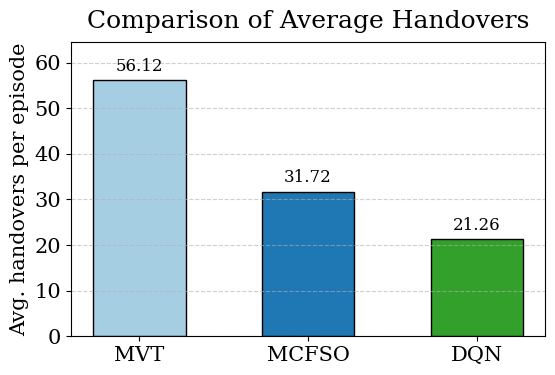

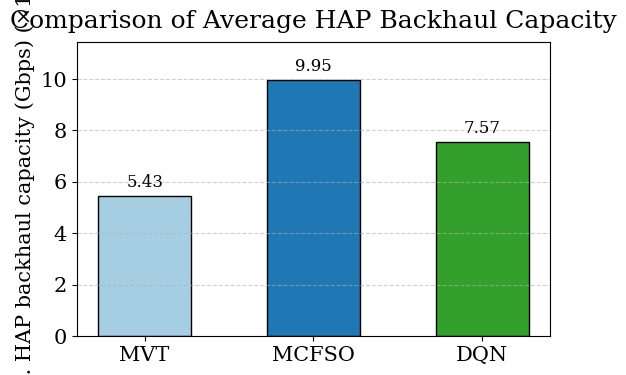

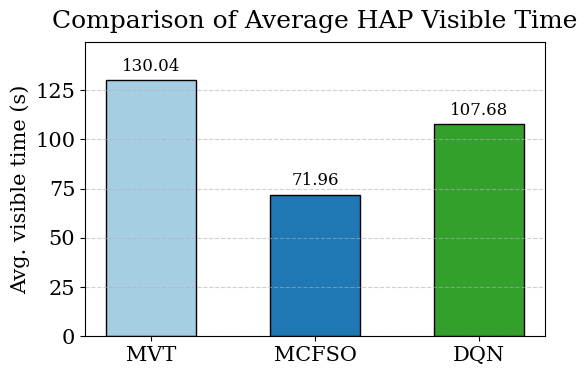

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# ======= FONT & STYLE CHUẨN BÀI BÁO =======
matplotlib.rcParams.update({
    'font.family': 'DeJavu Serif',
    'font.serif': ['Times New Roman'],
    'font.size': 15,
})

def bar_plot(labels, values, ylabel, title):
    plt.figure(figsize=(5.8,4))
    
    # --- chuẩn hóa & rút gọn số lớn ---
    scale_text = ""
    if np.max(values) > 1000:
        values = np.array(values) / 1e9
        scale_text = " (×10³)"
    
    bars = plt.bar(labels, values, width=0.55,
                   color=['#A6CEE3','#1F78B4','#33A02C'],
                   edgecolor='black')
    
    plt.ylabel(ylabel + scale_text)
    plt.title(title, pad=10)
    
    # --- giới hạn trục Y để chừa chỗ cho text ---
    max_val = np.max(values)
    plt.ylim(0, max_val * 1.15)  # thêm 15% khoảng trống
    
    # --- hiển thị giá trị trên đầu cột (cao hơn một chút) ---
    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max_val * 0.02,   # đẩy text lên 2%
                 f"{val:.2f}",
                 ha='center', va='bottom', fontsize=12)
    
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()



handover_mean_DQN = np.mean([np.mean(x) for x in nums_handover_DQN_arr])
handover_mean_random = np.mean([np.mean(x) for x in nums_handover_visible_arr])
handover_mean_best = np.mean([np.mean(x) for x in nums_handover_best_arr])

bar_plot(["MVT", "MCFSO", "DQN"],
         [handover_mean_random, handover_mean_best, handover_mean_DQN],
         ylabel="Avg. handovers per episode",
         title="Comparison of Average Handovers")


hap_bw_mean_DQN = np.mean([np.mean(x) for x in HAP_bw_log_DQN_arr])
hap_bw_mean_random = np.mean([np.mean(x) for x in HAP_bw_log_visible_arr])
hap_bw_mean_best = np.mean([np.mean(x) for x in HAP_bw_log_best_arr])

bar_plot(["MVT", "MCFSO", "DQN"],
         [hap_bw_mean_random, hap_bw_mean_best, hap_bw_mean_DQN],
         ylabel="Avg. HAP backhaul capacity (Gbps)",
         title="Comparison of Average HAP Backhaul Capacity")


visible_mean_DQN = np.mean([np.mean(x) for x in visible_log_DQN_arr])
visible_mean_random = np.mean([np.mean(x) for x in visible_log_visible_arr])
visible_mean_best = np.mean([np.mean(x) for x in visible_log_best_arr])

bar_plot(["MVT", "MCFSO", "DQN"],
         [visible_mean_random, visible_mean_best, visible_mean_DQN],
         ylabel="Avg. visible time (s)",
         title="Comparison of Average HAP Visible Time")


In [16]:
# import json

# # Ví dụ log JSON bạn có:
# log_line = '''
# {
#   "handover": {
#     "DQN": 17.99,
#     "Visible": 58.11,
#     "MaxCFSO": 32.49
#   },
#   "hap_bw": {
#     "DQN": 9998748847.80936,
#     "Visible": 6973999727.87841,
#     "MaxCFSO": 12854878348.5917
#   },
#   "hap_visible": {
#     "DQN": 104.227455555556,
#     "Visible": 130.335866666667,
#     "MaxCFSO": 71.8840888888889
#   }
# }
# '''

# # Parse chuỗi JSON
# results = json.loads(log_line)

# # Lấy ra từng giá trị
# handover_mean_DQN = results["handover"]["DQN"]
# handover_mean_random = results["handover"]["Visible"]
# handover_mean_best = results["handover"]["MaxCFSO"]

# hap_bw_mean_DQN = results["hap_bw"]["DQN"]
# hap_bw_mean_random = results["hap_bw"]["Visible"]
# hap_bw_mean_best = results["hap_bw"]["MaxCFSO"]

# visible_mean_DQN = results["hap_visible"]["DQN"]
# visible_mean_random = results["hap_visible"]["Visible"]
# visible_mean_best = results["hap_visible"]["MaxCFSO"]

# # In ra
# print("Handover:", handover_DQN, handover_visible, handover_maxcfso)
# print("HAP BW:", hap_bw_DQN, hap_bw_visible, hap_bw_maxcfso)
# print("HAP Visible:", hap_visible_DQN, hap_visible_visible, hap_visible_maxcfso)


/tmp/ipykernel_19/1323309107.py:84: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patches = [mpatches.Patch(color=c, label=l, edgecolor='black') for c, l in zip(colors, labels)]


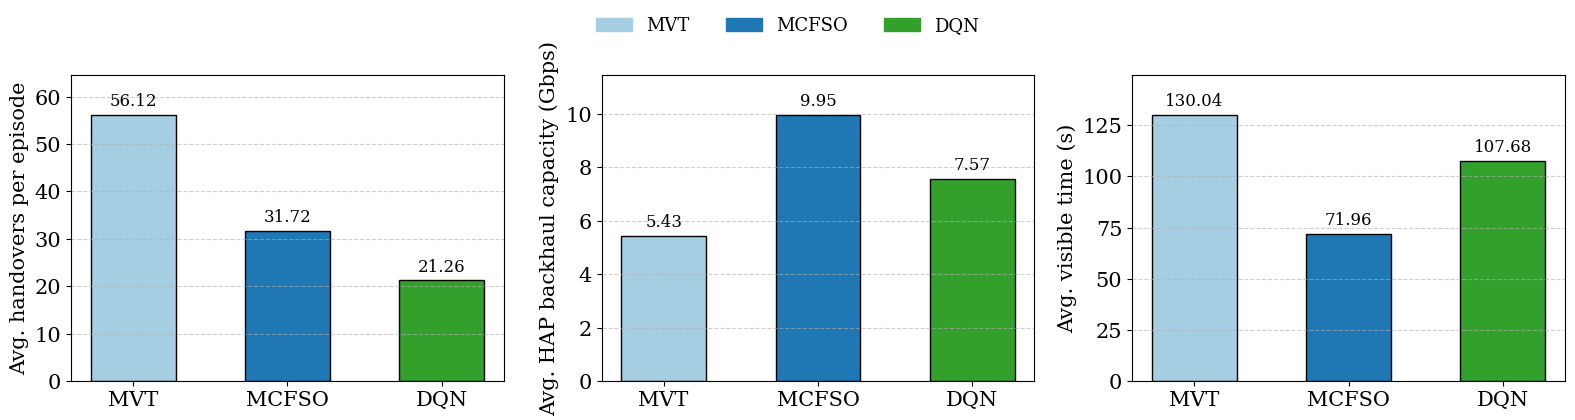

✅ Saved as 'comparison_results_with_legend.pdf' with top legend.


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib

# ======= FONT & STYLE CHUẨN BÀI BÁO =======
matplotlib.rcParams.update({
    'font.family': 'DeJavu Serif',
    'font.serif': ['Times New Roman'],
    'font.size': 15,
})

# ======= DỮ LIỆU (ví dụ bạn thay bằng dữ liệu thật của bạn) =======
# handover_mean_DQN = np.mean([np.mean(x) for x in nums_handover_DQN_arr])
# handover_mean_random = np.mean([np.mean(x) for x in nums_handover_visible_arr])
# handover_mean_best = np.mean([np.mean(x) for x in nums_handover_best_arr])

# hap_bw_mean_DQN = np.mean([np.mean(x) for x in HAP_bw_log_DQN_arr])
# hap_bw_mean_random = np.mean([np.mean(x) for x in HAP_bw_log_visible_arr])
# hap_bw_mean_best = np.mean([np.mean(x) for x in HAP_bw_log_best_arr])

# visible_mean_DQN = np.mean([np.mean(x) for x in visible_log_DQN_arr])
# visible_mean_random = np.mean([np.mean(x) for x in visible_log_visible_arr])
# visible_mean_best = np.mean([np.mean(x) for x in visible_log_best_arr])


# ======= HÀM VẼ BAR CHUNG =======
def draw_bar(ax, labels, values, ylabel, title, auto_scale=False):
    """auto_scale=True sẽ tự chia giá trị cho 1e3 hoặc 1e9 nếu quá lớn."""
    scale_text = ""
    vals = np.array(values, dtype=float)

    if auto_scale:
        if np.max(vals) > 1e9:
            vals /= 1e9
            scale_text = ""
        elif np.max(vals) > 1e6:
            vals /= 1e6
            scale_text = " "
        elif np.max(vals) > 1e3:
            vals /= 1e3
            scale_text = " (×10³)"

    colors = ['#A6CEE3', '#1F78B4', '#33A02C']
    bars = ax.bar(labels, vals, width=0.55,
                  color=colors, edgecolor='black')

    ax.set_ylabel(ylabel + scale_text)
    ax.set_title(title, pad=10)
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    max_val = np.max(vals)
    ax.set_ylim(0, max_val * 1.15)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max_val * 0.02,
                f"{val:.2f}",
                ha='center', va='bottom', fontsize=12)


# ======= VẼ 3 BIỂU ĐỒ NGANG =======
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

draw_bar(axes[0], ["MVT", "MCFSO", "DQN"],
          [handover_mean_random, handover_mean_best, handover_mean_DQN],
          ylabel="Avg. handovers per episode",
          title="")

draw_bar(axes[1], ["MVT", "MCFSO", "DQN"],
          [hap_bw_mean_random, hap_bw_mean_best, hap_bw_mean_DQN],
          ylabel="Avg. HAP backhaul capacity (Gbps)",
          title="",
          auto_scale=True)

draw_bar(axes[2], ["MVT", "MCFSO", "DQN"],
          [visible_mean_random, visible_mean_best, visible_mean_DQN],
          ylabel="Avg. visible time (s)",
          title="")

# ======= THÊM LEGEND Ở TRÊN =======
colors = ['#A6CEE3', '#1F78B4', '#33A02C']
labels = ['MVT', 'MCFSO', 'DQN']
patches = [mpatches.Patch(color=c, label=l, edgecolor='black') for c, l in zip(colors, labels)]

fig.legend(handles=patches,
           loc='upper center',
           ncol=3,
           fontsize=13,
           frameon=False,
           bbox_to_anchor=(0.5, 1.08))  # vị trí legend ở giữa phía trên

plt.tight_layout(rect=[0, 0, 1, 0.95])  # chừa chỗ cho legend
plt.savefig("/kaggle/working/comparison_result.pdf", bbox_inches='tight')
plt.show()
plt.close()

print("✅ Saved as 'comparison_results_with_legend.pdf' with top legend.")
